/home/gaochi/miniconda3/envs/plot/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


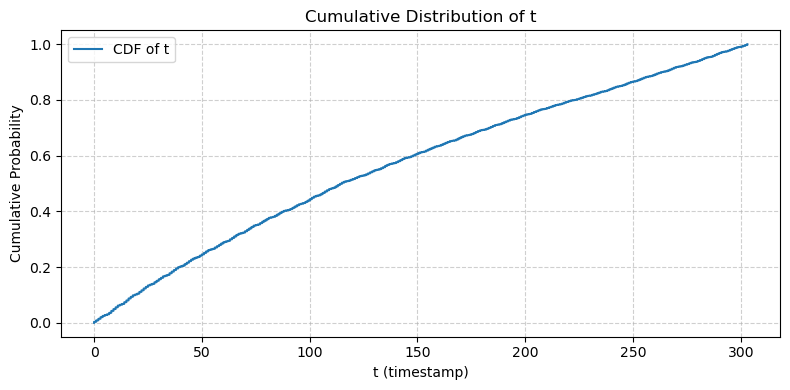


=== Quantile thresholds (CDF ≤ q) ===
Quantile 0.1: t ≤ 19
Quantile 0.2: t ≤ 40
Quantile 0.3: t ≤ 64
Quantile 0.4: t ≤ 88
Quantile 0.5: t ≤ 115
Quantile 0.6: t ≤ 148
Quantile 0.7: t ≤ 184
Quantile 0.8: t ≤ 223
Quantile 0.9: t ≤ 264


In [2]:
import torch
import matplotlib.pyplot as plt
from torch_geometric.datasets import ICEWS18


def load_icews18(root: str):
    train_dataset = ICEWS18(root, split='train')
    val_dataset = ICEWS18(root, split='val')
    test_dataset = ICEWS18(root, split='test')
    
    dataset = train_dataset
    dataset.data.sub = torch.cat([train_dataset.data.sub, val_dataset.data.sub, test_dataset.data.sub], dim=0)
    dataset.data.obj = torch.cat([train_dataset.data.obj, val_dataset.data.obj, test_dataset.data.obj], dim=0)
    dataset.data.rel = torch.cat([train_dataset.data.rel, val_dataset.data.rel, test_dataset.data.rel], dim=0)
    dataset.data.t = torch.cat([train_dataset.data.t, val_dataset.data.t, test_dataset.data.t], dim=0)
        
    edge_index = []
    unique_set = set()

    for u, v, t in zip(dataset.data.sub, dataset.data.obj, dataset.data.t):
        key = (u.item(), v.item())
        if key in unique_set:
            continue
        unique_set.add(key)
        edge_index.append((u.item(), v.item(), t.item()))

    dataset.data.edge_index = torch.tensor(edge_index, dtype=torch.int64).t()  # shape (3, E)
    return dataset


def plot_t_cdf(dataset):
    # 提取时间戳并排序
    t = dataset.data.edge_index[2]
    t_sorted, _ = torch.sort(t)
    n = len(t_sorted)

    # 累计分布函数
    cdf = torch.arange(1, n + 1, dtype=torch.float32) / n

    # 绘制累计分布曲线
    plt.figure(figsize=(8, 4))
    plt.plot(t_sorted.numpy(), cdf.numpy(), label='CDF of t')
    plt.xlabel('t (timestamp)')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Distribution of t')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 计算 0.1, ..., 0.9 分度值
    quantiles = torch.tensor([0.1 * i for i in range(1, 10)], dtype=torch.float32)
    quantile_t = []

    for q in quantiles:
        idx = (cdf <= q).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            quantile_t.append(t_sorted[idx[-1]].item())
        else:
            quantile_t.append(float('nan'))

    print("\n=== Quantile thresholds (CDF ≤ q) ===")
    for q, tq in zip(quantiles, quantile_t):
        print(f"Quantile {q.item():.1f}: t ≤ {tq}")


if __name__ == "__main__":
    # 数据加载路径请根据实际情况修改
    root = "./datasets/icews18"
    dataset = load_icews18(root)
    plot_t_cdf(dataset)
